# Chassis Impact Detector - Training

Trains the lightweight CNN on the log-mel spectrogram windows produced by Stage 2
(`ai_audio/pipeline/preprocessing/make_features.py`, run on the Pi), then exports the result
to ONNX for Stage 4 (NCNN inference back on the Pi).

**Before running:**
1. On the Pi: `cd ai_audio/pipeline/dataset && zip -r processed_dataset.zip processed`
2. Upload `processed_dataset.zip` as a new Kaggle Dataset (kaggle.com -> Datasets -> New Dataset).
3. Attach that dataset to this notebook (right sidebar -> Add Input).
4. Turn on a GPU accelerator: Settings -> Accelerator -> GPU T4 x2 (or P100).
5. Set `INPUT_DIR` in the next config cell to match your attached dataset's mount path.

**Every run: use Kernel -> Restart & Run All.** Cells share global state and must execute in
order top-to-bottom -- re-running an individual cell after changing something upstream (e.g.
tweaking `EPOCHS` and re-running just the training cell) silently trains on stale objects
(old `model`, old `train_loader`, etc.) instead of picking up the change. There is no
`if __name__ == "__main__"` boundary or per-cell isolation to catch this.

**Long continuous recordings (few files, each spanning minutes, instead of many short clips):**
run Stage 2 with `--event-detect-labels` for any label whose long files have scattered
impact events (e.g. `hit`, `background_self_fire`) so windows land on each event instead
of arbitrary fixed slices, and make sure your `manifest.csv` has the `start_sec`/`duration_sec`
columns (current `make_features.py` writes these automatically). The split cell below
(`time_block_split`) then automatically falls back from whole-file holdout to a purged
within-file time-block split for any label with too few distinct source files -- see its
docstring for why.


In [4]:
import csv, datetime, glob, json, os, random, re
from collections import defaultdict, Counter

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

print("torch:", torch.__version__, "cuda available:", torch.cuda.is_available())


torch: 2.10.0+cu128 cuda available: True


In [5]:
KAGGLE_INPUT_ROOT = "/kaggle/input"
OUTPUT_DIR = "/kaggle/working"

# Raw recording labels that collapse into a single training class.
LABEL_MAP = {
    "background_self_fire": "background",
}

# Continuous-session labels: adjacent chunks are near-duplicates, so they need session-aware splitting.
CONTINUOUS_LABELS = {"background"}

# Max gap between files still counted as one continuous recording session.
SESSION_GAP_SECONDS = 30.0

# Purge band dropped from both sides of a single-session train/val cut.
GUARD_SECONDS = 8.0

# Test fraction carved out before the train/val split; checkpoint selection never sees it.
TEST_FRAC = 0.15
VAL_FRAC = 0.2
EPOCHS = 40
BATCH_SIZE = 16
LR = 3e-4  # Adam + BatchNorm + batch_size=16 + heavy class-imbalance oversampling produces occasional loss spikes (up to 5x+) even with gradient clipping; a small LR shrinks every step regardless of Adam's adaptive scaling, which clipping alone doesn't fully control
SEED = 42

# ImpactCNN conv block output channels, in order -- depth is len(CONV_CHANNELS).
CONV_CHANNELS = (16, 32, 64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


In [6]:
def find_manifest(search_root=KAGGLE_INPUT_ROOT):
    """Locate manifest.csv anywhere under search_root; Kaggle mount paths are never stable."""
    candidates = sorted(glob.glob(os.path.join(search_root, "**", "manifest.csv"), recursive=True))

    if not candidates:
        raise FileNotFoundError(
            f"No manifest.csv found anywhere under {search_root}. Make sure your "
            "processed-dataset zip is attached to this notebook (right sidebar -> "
            "Add Input) and that it actually contains manifest.csv."
        )

    if len(candidates) == 1:
        print(f"Found manifest.csv: {candidates[0]}")
        return candidates[0]

    print(f"Found {len(candidates)} manifest.csv files under {search_root}:")
    for c in candidates:
        print(f"  - {c}  (modified {datetime.datetime.fromtimestamp(os.path.getmtime(c))})")
    chosen = max(candidates, key=os.path.getmtime)
    print(f"Multiple candidates found -- using the most recently modified: {chosen}")
    print("If that's the wrong one, pass search_root explicitly, or delete the stale input.")
    return chosen


def find_file(filename, search_root=KAGGLE_INPUT_ROOT):
    """Recursively locate filename under search_root, as a fallback when the manifest-relative path misses."""
    return sorted(glob.glob(os.path.join(search_root, "**", filename), recursive=True))


def resolve_npy_path(processed_dir, relative_path):
    """Resolve a manifest-relative .npy path, falling back to a recursive search."""
    direct = os.path.join(processed_dir, relative_path)
    if os.path.exists(direct):
        return direct
    matches = find_file(os.path.basename(relative_path))
    if not matches:
        raise FileNotFoundError(
            f"Could not locate {relative_path} under {processed_dir} or anywhere "
            f"under {KAGGLE_INPUT_ROOT}."
        )
    return matches[0]


def load_manifest():
    manifest_path = find_manifest()
    processed_dir = os.path.dirname(manifest_path)
    with open(manifest_path, newline="") as f:
        rows = list(csv.DictReader(f))
    for r in rows:
        r["raw_label"] = r["label"]  # preserved for post-hoc analysis (e.g. FP source breakdown)
        r["label"] = LABEL_MAP.get(r["label"], r["label"])
    return rows, processed_dir


rows, INPUT_DIR = load_manifest()
labels = sorted(set(r["label"] for r in rows))
label_to_idx = {label: i for i, label in enumerate(labels)}
print("labels:", label_to_idx)
print("total windows:", len(rows))
for label in labels:
    print(" ", label, sum(1 for r in rows if r["label"] == label))


Found manifest.csv: /kaggle/input/datasets/yahavbbbb/processed-dataset-5/processed/manifest.csv
labels: {'background': 0, 'hit': 1}
total windows: 5439
  background 4836
  hit 603


In [7]:
FILENAME_TS_RE = re.compile(r"_(\d{8})_(\d{6})_(\d+)_\d+\.wav$")


def parse_timestamp(source_wav):
    """Pull the wall-clock write time out of a <label>_<YYYYMMDD>_<HHMMSS>_<frac>_<idx>.wav name."""
    m = FILENAME_TS_RE.search(source_wav)
    date, time_, frac = m.group(1), m.group(2), m.group(3)
    ts = datetime.datetime.strptime(date + time_, "%Y%m%d%H%M%S")
    return ts + datetime.timedelta(microseconds=int(frac.ljust(6, "0")[:6]))


def build_sessions(file_rows_by_file, gap_seconds):
    """Group {source_wav: rows} into chronological sessions, splitting wherever a gap exceeds gap_seconds."""
    file_span = {}
    for source_wav, rows in file_rows_by_file.items():
        ts = parse_timestamp(source_wav)
        duration = max(float(r["start_sec"]) + float(r["duration_sec"]) for r in rows)
        file_span[source_wav] = (ts, duration)

    ordered = sorted(file_span, key=lambda f: file_span[f][0])
    sessions = []
    current = []
    prev_end = None
    for f in ordered:
        ts, duration = file_span[f]
        if prev_end is not None and (ts - prev_end).total_seconds() > gap_seconds:
            sessions.append(current)
            current = []
        current.append(f)
        prev_end = ts + datetime.timedelta(seconds=duration)
    if current:
        sessions.append(current)
    return sessions, file_span


def time_block_split(rows, val_frac, seed, continuous_labels=CONTINUOUS_LABELS,
                      gap_seconds=SESSION_GAP_SECONDS, guard_seconds=GUARD_SECONDS):
    """Split per label: whole-file holdout for discrete events, session-aware (or purged single-session) holdout for continuous_labels."""
    rows_by_label = defaultdict(list)
    for r in rows:
        rows_by_label[r["label"]].append(r)

    rng = random.Random(seed)
    train_rows, val_rows = [], []

    for label, label_rows in rows_by_label.items():
        if label not in continuous_labels:
            files = sorted(set(r["source_wav"] for r in label_rows))
            rng.shuffle(files)
            n_val = max(1, round(len(files) * val_frac))
            val_files = set(files[:n_val])
            for r in label_rows:
                (val_rows if r["source_wav"] in val_files else train_rows).append(r)
            continue

        by_file = defaultdict(list)
        for r in label_rows:
            by_file[r["source_wav"]].append(r)
        sessions, file_span = build_sessions(by_file, gap_seconds)

        if len(sessions) >= 2:
            session_sizes = [sum(len(by_file[f]) for f in s) for s in sessions]
            order = list(range(len(sessions)))
            rng.shuffle(order)
            target_val = round(sum(session_sizes) * val_frac)
            val_session_idx, running = set(), 0
            for i in order:
                if running >= target_val:
                    break
                val_session_idx.add(i)
                running += session_sizes[i]
            for i, session in enumerate(sessions):
                dest = val_rows if i in val_session_idx else train_rows
                for f in session:
                    dest.extend(by_file[f])
        else:
            session = sessions[0]
            session_start = min(file_span[f][0] for f in session)
            session_end = max((file_span[f][0] + datetime.timedelta(seconds=file_span[f][1]) - session_start).total_seconds() for f in session)
            split_point = session_end * (1 - val_frac)

            for f in session:
                offset = (file_span[f][0] - session_start).total_seconds()
                for r in by_file[f]:
                    start = offset + float(r["start_sec"])
                    end = start + float(r["duration_sec"])
                    if end <= split_point - guard_seconds:
                        train_rows.append(r)
                    elif start >= split_point + guard_seconds:
                        val_rows.append(r)
                    # else: inside the guard band around the cut -- dropped from both sets

    return train_rows, val_rows


# Two-stage split; the 1/(1 - TEST_FRAC) scaling keeps proportions relative to the original pool.
trainval_rows, test_rows = time_block_split(rows, TEST_FRAC, SEED)
train_rows, val_rows = time_block_split(trainval_rows, VAL_FRAC / (1 - TEST_FRAC), SEED + 1)
print(f"train windows: {len(train_rows)}  val windows: {len(val_rows)}  test windows: {len(test_rows)}")

for label in labels:
    label_rows = [r for r in rows if r["label"] == label]
    n_files = len(set(r["source_wav"] for r in label_rows))
    if label in CONTINUOUS_LABELS:
        sessions, _ = build_sessions(
            {r["source_wav"]: [rr for rr in label_rows if rr["source_wav"] == r["source_wav"]] for r in label_rows},
            SESSION_GAP_SECONDS,
        )
        print(f"  {label}: {n_files} file(s) -> {len(sessions)} session(s) -> "
              f"{'whole-session holdout' if len(sessions) >= 2 else 'single-session purged time-block split'}")
    else:
        print(f"  {label}: {n_files} file(s) -> whole-file holdout (discrete events)")


train windows: 2671  val windows: 1557  test windows: 1211
  background: 325 file(s) -> 4 session(s) -> whole-session holdout
  hit: 246 file(s) -> whole-file holdout (discrete events)


In [8]:
def compute_stats(rows, processed_dir):
    """Return (mean, std, {path: array}); the cache lets SpecDataset skip re-loading."""
    cache = {r["path"]: np.load(resolve_npy_path(processed_dir, r["path"])) for r in rows}
    arr = np.stack(list(cache.values()))
    return float(arr.mean()), float(arr.std()), cache

mean, std, train_feat_cache = compute_stats(train_rows, INPUT_DIR)
print(f"train feature mean={mean:.3f} std={std:.3f}")

def spec_augment(feat, freq_mask=8, time_mask=12):
    feat = feat.copy()
    n_mels, n_frames = feat.shape
    f0 = random.randint(0, max(0, n_mels - freq_mask))
    feat[f0:f0 + freq_mask, :] = 0.0
    t0 = random.randint(0, max(0, n_frames - time_mask))
    feat[:, t0:t0 + time_mask] = 0.0
    return feat

class SpecDataset(Dataset):
    def __init__(self, rows, processed_dir, label_to_idx, mean, std, augment, cache=None):
        self.rows = rows
        self.processed_dir = processed_dir
        self.label_to_idx = label_to_idx
        self.mean = mean
        self.std = std
        self.augment = augment
        self.cache = cache or {}  # optional preloaded {path: array}, see compute_stats

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        feat = self.cache.get(row["path"])
        if feat is None:
            feat = np.load(resolve_npy_path(self.processed_dir, row["path"]))
        feat = (feat - self.mean) / self.std
        if self.augment:
            feat = spec_augment(feat)
        x = torch.from_numpy(feat).float().unsqueeze(0)
        y = self.label_to_idx[row["label"]]
        return x, y

train_ds = SpecDataset(train_rows, INPUT_DIR, label_to_idx, mean, std, augment=True, cache=train_feat_cache)
val_ds = SpecDataset(val_rows, INPUT_DIR, label_to_idx, mean, std, augment=False)
test_ds = SpecDataset(test_rows, INPUT_DIR, label_to_idx, mean, std, augment=False)

class_counts = defaultdict(int)
for r in train_rows:
    class_counts[r["label"]] += 1
sample_weights = [1.0 / class_counts[r["label"]] for r in train_rows]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(train_rows), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

sample_x, _ = train_ds[0]
print("model input shape:", tuple(sample_x.shape))


train feature mean=-59.834 std=16.181
model input shape: (1, 64, 26)


In [9]:
class ImpactCNN(nn.Module):
    def __init__(self, n_classes=2, channels=CONV_CHANNELS):
        super().__init__()
        layers = []
        in_ch = 1
        for out_ch in channels:
            layers += [nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(), nn.MaxPool2d(2)]
            in_ch = out_ch
        # last block pools straight to 1x1 instead of /2, so the classifier's
        # input size is always channels[-1] regardless of spectrogram size
        layers[-1] = nn.AdaptiveAvgPool2d(1)
        self.features = nn.Sequential(*layers)
        self.classifier = nn.Linear(channels[-1], n_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ImpactCNN(n_classes=len(labels), channels=CONV_CHANNELS).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"device: {device}, params: {n_params:,}")


device: cuda, params: 23,650


In [10]:
def evaluate(model, loader, device, criterion=None):
    model.eval()
    tp = tn = fp = fn = 0
    total_loss, n = 0.0, 0
    hit_idx = label_to_idx.get("hit", 1)
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            if criterion is not None:
                total_loss += criterion(logits, y).item() * x.size(0)
                n += x.size(0)
            pred = logits.argmax(1)
            for p, t in zip(pred.tolist(), y.tolist()):
                tp += p == hit_idx and t == hit_idx
                tn += p != hit_idx and t != hit_idx
                fp += p == hit_idx and t != hit_idx
                fn += p != hit_idx and t == hit_idx
    total = tp + tn + fp + fn
    accuracy = (tp + tn) / total if total else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1,
            "tp": tp, "tn": tn, "fp": fp, "fn": fn,
            "loss": (total_loss / n) if n else None}


def collect_predictions(model, loader, device):
    model.eval()
    preds = []
    with torch.no_grad():
        for x, _ in loader:
            preds.extend(model(x.to(device)).argmax(1).cpu().tolist())
    return preds


In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

# Non-augmented, non-resampled view of the training set, for a train metric comparable to val.
train_eval_ds = SpecDataset(train_rows, INPUT_DIR, label_to_idx, mean, std, augment=False, cache=train_feat_cache)
train_eval_loader = DataLoader(train_eval_ds, batch_size=BATCH_SIZE, shuffle=False)

os.makedirs(OUTPUT_DIR, exist_ok=True)
best_f1 = -1.0
best_state = None
history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        # Caps the step size when oversampling and augmentation produce an outlier gradient.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

    train_metrics = evaluate(model, train_eval_loader, device, criterion)
    val_metrics = evaluate(model, val_loader, device, criterion)
    history["train_loss"].append(train_metrics["loss"])
    history["val_loss"].append(val_metrics["loss"])
    history["train_f1"].append(train_metrics["f1"])
    history["val_f1"].append(val_metrics["f1"])

    print(
        f"epoch {epoch:3d}  train_loss={train_metrics['loss']:.4f}  val_loss={val_metrics['loss']:.4f}  "
        f"train_f1={train_metrics['f1']:.3f}  val_f1={val_metrics['f1']:.3f}  "
        f"(tp={val_metrics['tp']} fp={val_metrics['fp']} fn={val_metrics['fn']} tn={val_metrics['tn']})"
    )

    # >= (not >): on a tie the later epoch wins, favoring the more-trained model.
    if val_metrics["f1"] >= best_f1:
        best_f1 = val_metrics["f1"]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
print(f"best val f1={best_f1:.3f}")


epoch   1  train_loss=0.2793  val_loss=3.0931  train_f1=0.666  val_f1=0.121  (tp=93 fp=1326 fn=28 tn=110)
epoch   2  train_loss=0.2863  val_loss=1.1000  train_f1=0.768  val_f1=0.167  (tp=92 fp=886 fn=29 tn=550)
epoch   3  train_loss=0.2270  val_loss=1.7533  train_f1=0.771  val_f1=0.157  (tp=92 fp=959 fn=29 tn=477)
epoch   4  train_loss=0.2291  val_loss=1.8193  train_f1=0.767  val_f1=0.157  (tp=93 fp=973 fn=28 tn=463)
epoch   5  train_loss=0.1993  val_loss=0.6204  train_f1=0.806  val_f1=0.298  (tp=92 fp=404 fn=29 tn=1032)
epoch   6  train_loss=0.2457  val_loss=1.3468  train_f1=0.765  val_f1=0.259  (tp=98 fp=537 fn=23 tn=899)
epoch   7  train_loss=0.2647  val_loss=0.7842  train_f1=0.787  val_f1=0.287  (tp=100 fp=475 fn=21 tn=961)
epoch   8  train_loss=0.2143  val_loss=1.4641  train_f1=0.784  val_f1=0.222  (tp=102 fp=695 fn=19 tn=741)
epoch   9  train_loss=0.2563  val_loss=0.9966  train_f1=0.827  val_f1=0.240  (tp=104 fp=643 fn=17 tn=793)
epoch  10  train_loss=0.2131  val_loss=0.4170  tra

test set: accuracy=0.966 precision=0.857 recall=0.659 f1=0.745
test set composition by original recording source:
  background: 1120 windows (train has 2280)
  hit: 91 windows (train has 391)


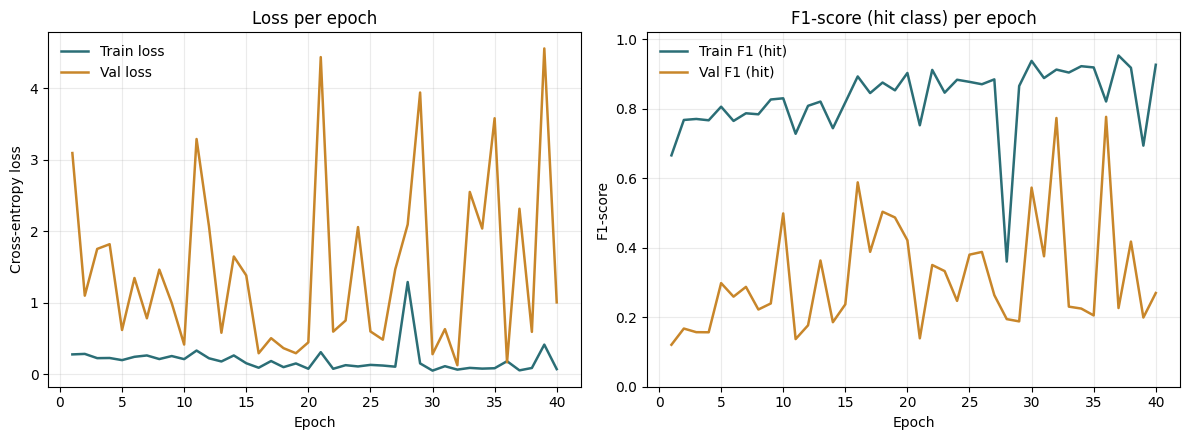

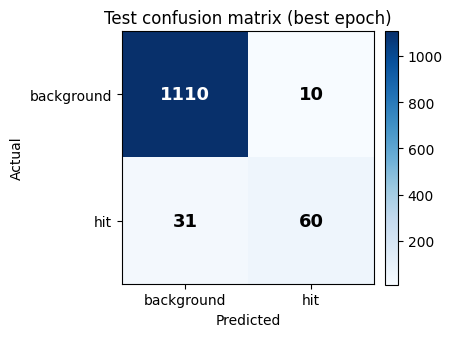

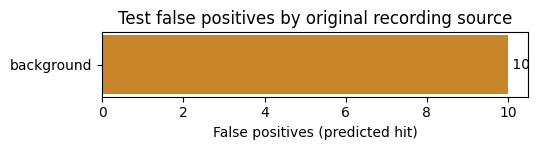

In [12]:
idx_to_label = {i: label for label, i in label_to_idx.items()}
hit_idx = label_to_idx.get("hit", 1)

test_metrics = evaluate(model, test_loader, device)
print(f"test set: accuracy={test_metrics['accuracy']:.3f} precision={test_metrics['precision']:.3f} "
      f"recall={test_metrics['recall']:.3f} f1={test_metrics['f1']:.3f}")

test_preds = collect_predictions(model, test_loader, device)
test_targets = [label_to_idx[r["label"]] for r in test_rows]

test_raw_counts = Counter(r.get("raw_label", r["label"]) for r in test_rows)
train_raw_counts = Counter(r.get("raw_label", r["label"]) for r in train_rows)
print("test set composition by original recording source:")
for src_label, n in test_raw_counts.items():
    print(f"  {src_label}: {n} windows (train has {train_raw_counts.get(src_label, 0)})")
    if train_raw_counts.get(src_label, 0) == 0 and test_raw_counts.get(src_label, 0) > 0:
        print(f"    NOTE: {src_label} has zero training windows -- it's entirely held out this run.")

n_classes = len(label_to_idx)
cm = np.zeros((n_classes, n_classes), dtype=int)
for t, p in zip(test_targets, test_preds):
    cm[t, p] += 1

fp_by_source = Counter()
for r, t, p in zip(test_rows, test_targets, test_preds):
    if p == hit_idx and t != hit_idx:
        fp_by_source[r.get("raw_label", r["label"])] += 1


def plot_training_curves(history, out_dir):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    ax = axes[0]
    ax.plot(epochs, history["train_loss"], label="Train loss", color="#2b6e76", linewidth=1.8)
    ax.plot(epochs, history["val_loss"], label="Val loss", color="#c8862a", linewidth=1.8)
    ax.set_title("Loss per epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)

    ax = axes[1]
    ax.plot(epochs, history["train_f1"], label="Train F1 (hit)", color="#2b6e76", linewidth=1.8)
    ax.plot(epochs, history["val_f1"], label="Val F1 (hit)", color="#c8862a", linewidth=1.8)
    ax.set_title("F1-score (hit class) per epoch")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("F1-score")
    ax.set_ylim(0, 1.02)
    ax.legend(frameon=False)
    ax.grid(alpha=0.25)

    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, "training_curves.png"), dpi=150)
    plt.show()


def plot_confusion_matrix(cm, class_names, out_dir):
    fig, ax = plt.subplots(figsize=(4.6, 4.2))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title("Test confusion matrix (best epoch)")

    thresh = cm.max() / 2 if cm.max() else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=13, fontweight="bold",
                    color="white" if cm[i, j] > thresh else "black")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, "confusion_matrix.png"), dpi=150)
    plt.show()


def plot_fp_breakdown(fp_by_source, out_dir):
    if not fp_by_source:
        print("No false positives in test set -- nothing to break down.")
        return
    names = list(fp_by_source.keys())
    counts = [fp_by_source[n] for n in names]
    fig, ax = plt.subplots(figsize=(5.5, 0.6 * len(names) + 1))
    ax.barh(names, counts, color="#c8862a")
    for i, c in enumerate(counts):
        ax.text(c, i, f" {c}", va="center")
    ax.set_xlabel("False positives (predicted hit)")
    ax.set_title("Test false positives by original recording source")
    fig.tight_layout()
    fig.savefig(os.path.join(out_dir, "fp_breakdown.png"), dpi=150)
    plt.show()


plot_training_curves(history, OUTPUT_DIR)
plot_confusion_matrix(cm, [idx_to_label[i] for i in range(n_classes)], OUTPUT_DIR)
plot_fp_breakdown(fp_by_source, OUTPUT_DIR)


In [13]:
model.eval().cpu()
sample_shape = tuple(sample_x.shape)  # (1, n_mels, n_frames)
dummy_input = torch.randn(1, *sample_shape)

onnx_path = os.path.join(OUTPUT_DIR, "impact_cnn.onnx")
torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    input_names=["spectrogram"],
    output_names=["logits"],
    opset_version=12,
    dynamic_axes=None,  # fixed shape on purpose -- must match Stage 4's window length exactly
    dynamo=False,  # force the legacy exporter -- the newer dynamo path needs the onnxscript package, not installed by default
)
print("exported", onnx_path)

with open(os.path.join(OUTPUT_DIR, "labels.json"), "w") as f:
    json.dump(label_to_idx, f, indent=2)
with open(os.path.join(OUTPUT_DIR, "feature_stats.json"), "w") as f:
    json.dump({"mean": mean, "std": std, "input_shape": list(sample_shape)}, f, indent=2)

print("labels.json and feature_stats.json written to", OUTPUT_DIR)


/tmp/ipykernel_58/1481461429.py:6: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


exported /kaggle/working/impact_cnn.onnx
labels.json and feature_stats.json written to /kaggle/working


In [14]:
!pip install -q onnxruntime

import onnxruntime as ort

sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
with torch.no_grad():
    torch_out = model(dummy_input).numpy()
onnx_out = sess.run(None, {"spectrogram": dummy_input.numpy()})[0]

max_diff = np.abs(torch_out - onnx_out).max()
print("max abs diff torch vs onnx:", max_diff)
assert max_diff < 1e-4, "ONNX export mismatch!"
print("ONNX export verified.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 72.2 MB/s eta 0:00:00:00:0100:01
max abs diff torch vs onnx: 5.722046e-06
ONNX export verified.


## Done

Download these three files from the notebook's **Output** panel (`/kaggle/working`) and copy them
to `ai_audio/onboard/model/` on the Pi for Stage 4:

- `impact_cnn.onnx`
- `labels.json`
- `feature_stats.json`
